# Generating the target geometry

In [1]:
import numpy as np


### Target data

In [ ]:
#Radius
SHELL_RADIUS= 0.001 #meter
DT_SHELL_RADIUS= 0.000955 #meter
DT_ICE_RADIUS= 0.000755 #meter

#Densities
SHELL_DENSITY= 1.05 #g/cm3
DT_SHELL_DENSITY= 0.25 #g/cm3
DT_ICE_DENSITY= 0.0003 #g/cm3

### Target geometry

In [ ]:
def generate_sphere(radius,N):
    'generates a sphere by points'
    theta = np.linspace(0, 2*np.pi,N)
    R=radius*np.cos(theta)
    Z=radius*np.sin(theta)

    return pd.DataFrame({'R': R, 'Z': Z})

N_points=1000

#Creating the 3 contours for ARWEN
Contour_1=generate_sphere(SHELL_RADIUS,N_points)
Contour_2=generate_sphere(DT_SHELL_RADIUS,N_points)
Contour_3=generate_sphere(DT_ICE_RADIUS,N_points)

### Showing target in 2D

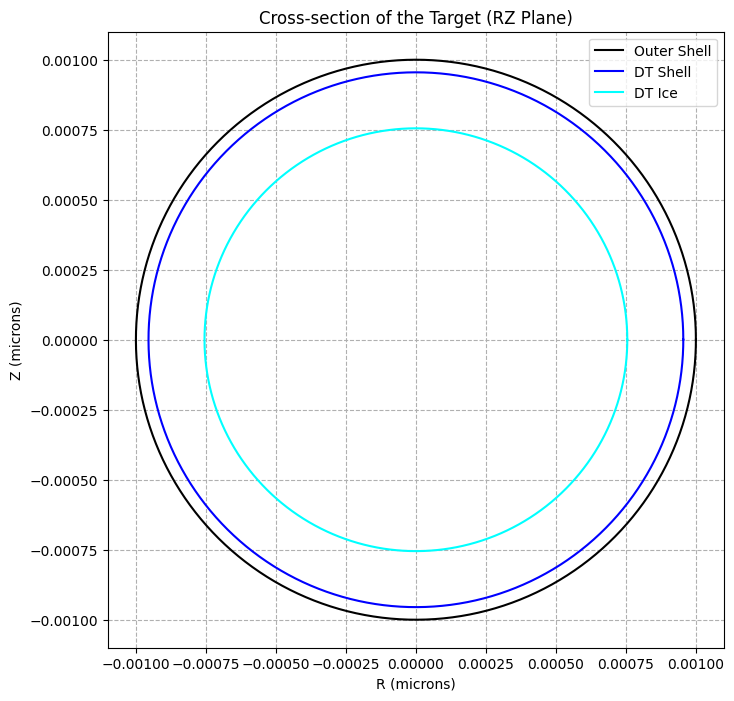

In [ ]:
import matplotlib.pyplot as plt

# On crée la figure
plt.figure(figsize=(8, 8))

# On trace chaque contour avec une couleur et un nom différent
plt.plot(Contour_1['R'], Contour_1['Z'], label='Outer Shell', color='black')
plt.plot(Contour_2['R'], Contour_2['Z'], label='DT Shell', color='blue')
plt.plot(Contour_3['R'], Contour_3['Z'], label='DT Ice', color='cyan')

# On ajoute les détails pour que ce soit propre
plt.gca().set_aspect('equal') # Très important pour que le cercle ne ressemble pas à un œuf
plt.xlabel('R (microns)')
plt.ylabel('Z (microns)')
plt.title('Cross-section of the Target (RZ Plane)')
plt.legend()
plt.grid(True, linestyle='--')

plt.show()

### Target material definition

In [ ]:
#Region : shell
T=300 
ux= uy= 0

CH=[SHELL_DENSITY,T, ux, uy]

#Region : DT shell
DT_gas=[DT_SHELL_DENSITY,T]

#Region : DT ice
DT_ice=[DT_ICE_DENSITY,T]


## Definition on the rays in a plan grid

Definition of the grid

In [ ]:
def generate_square_grid_beam(num_points_side=50, window_radius=0.30):
    """
    Generates a regular (square) grid of rays instead of a random sampling.
    Useful for providing deterministic inputs to the ARWEN software.
    """
    # 1. Create the U, V coordinate grid (the square bounding the beam)
    u = np.linspace(-window_radius, window_radius, num_points_side)
    v = np.linspace(-window_radius, window_radius, num_points_side)
    uu, vv = np.meshgrid(u, v) # Creates the grid

    # Calculate the elementary area (dS) for each ray (pixel)
    du = u[1] - u[0]
    dv = v[1] - v[0]
    dS = du * dv
    
    # 2. Filter rays to keep only those within the circular aperture (R <= beam_radius)
    mask = (uu**2 + vv**2) <= window_radius**2
    u_points = uu[mask].ravel()
    v_points = vv[mask].ravel()
    
    return u_points, v_points, dS # Local coordinates of the grid-based beam source

Grid shown

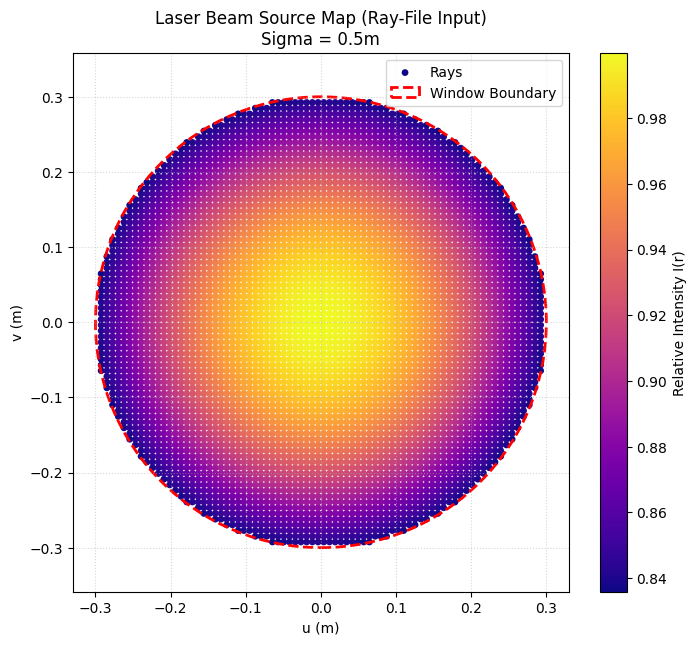

In [ ]:
import matplotlib.pyplot as plt

def plot_beam_grid(u, v, window_radius, sigma=0.5):
    """
    Visualizes the square grid sampling and the Gaussian intensity profile.
    """
    # Calculate intensity for coloring the points 
    intensity = np.exp(-(u**2 + v**2) / (2 * sigma**2))
    
    plt.figure(figsize=(8, 7))
    
    
    sc = plt.scatter(u, v, c=intensity, s=15, cmap='plasma', label='Rays')
    
    
    cbar = plt.colorbar(sc)
    cbar.set_label('Relative Intensity I(r)')
    
    
    circle = plt.Circle((0, 0), window_radius, color='red', fill=False, 
                        linestyle='--', linewidth=2, label='Window Boundary')
    plt.gca().add_patch(circle)
    
    plt.title(f"Laser Beam Source Map (Ray-File Input)\nSigma = {sigma}m")
    plt.xlabel("u (m)")
    plt.ylabel("v (m)")
    plt.axis('equal')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.5)
    
    plt.show()

u_pts, v_pts, dS = generate_square_grid_beam(num_points_side=80, window_radius=0.30)
plot_beam_grid(u_pts, v_pts, window_radius=0.30, sigma=0.5)
